# Day 45 (1/2) — K-Nearest Neighbors (K-NN) Classification

### The idea in one sentence
> **"Tell me who your neighbours are, and I'll tell you who you are."**

To classify a new point, K-NN looks at the **K closest points** in the training data and takes a **majority vote**.
There are no equations to fit and no weights to learn: the training data *is* the model.

### The business problem
A company shows social-network ads for a new SUV. For 400 users we know **Age**, **Estimated Salary**, and whether they
**Purchased** (1) or not (0). Can we predict who will buy?

### In this notebook
1. Explore the data
2. Scale the features (essential for K-NN)
3. Train K-NN, predict a new customer, and see *which* neighbours voted
4. Evaluate: confusion matrix, accuracy, precision and recall
5. Visualise the decision boundary
6. 🧪 Experiment: what happens **without** scaling?
7. 🎯 Choosing **K**: overfitting vs underfitting, and tuning with cross-validation

> 📖 Theory: [`theory.md`](theory.md) · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

## 1. Import libraries and load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#FA8072', '#1E90FF']          # 0 = did not buy (salmon), 1 = bought (blue)
CMAP = ListedColormap(COLORS)

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
print(dataset.shape)
dataset.head()

(400, 3)


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
dataset.describe().round(1)

,Age,EstimatedSalary,Purchased
count,400.0,400.0,400.0
mean,37.7,69742.5,0.4
std,10.5,34097.0,0.5
min,18.0,15000.0,0.0
25%,29.8,43000.0,0.0
50%,37.0,70000.0,0.0
75%,46.0,88000.0,1.0
max,60.0,150000.0,1.0


In [4]:
dataset['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

- 400 users, 2 features, 1 target.
- **Age** ranges 18–60, **Estimated Salary** ranges 15,000–150,000. The scales differ by a factor of ~3,000 (this matters in Section 2).
- 257 did not buy, 143 bought (≈ 64% / 36%). A model that always says "no" would already be ~64% accurate, so that is the baseline to beat.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

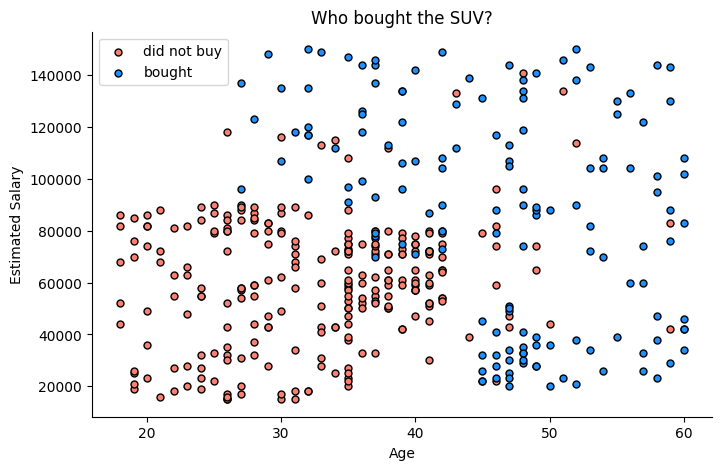

In [5]:
X_all = dataset[['Age', 'EstimatedSalary']].values
y_all = dataset['Purchased'].values
plt.figure(figsize=(8, 5))
for label in [0, 1]:
    plt.scatter(X_all[y_all == label, 0], X_all[y_all == label, 1], color=COLORS[label], edgecolor='k',
                s=25, label=['did not buy', 'bought'][label])
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Who bought the SUV?')
plt.legend()
plt.show()

Buyers (blue) are mostly **older** or **high-salary** users. The two classes overlap in the middle, and the boundary
between them is clearly **not a straight line**: a good fit for K-NN, which can draw any shape.

## 2. Split into training and test sets

> ✍️ **Core code: learn this.** Same split as before: 75% train, 25% test.

In [6]:
from sklearn.model_selection import train_test_split

X = dataset.iloc[:, :-1].values      # Age, EstimatedSalary
y = dataset.iloc[:, -1].values       # Purchased

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print(X_train.shape, X_test.shape)

(300, 2) (100, 2)


## 3. Feature scaling: not optional for K-NN

K-NN decides everything by **distance**. Take two users who differ by **10 years** of age and **1,000** of salary:

$$
d = \sqrt{10^2 + 1000^2} \approx 1000.05
$$

The age difference contributes almost nothing; salary alone decides who is "near". After **standardisation** (Day 7)
both features have mean 0 and standard deviation 1, so both count equally.

Fit the scaler on the **training set only**, then apply the same transformation to the test set (no data leakage).

> ✍️ **Core code: learn this.** Standardise both features.

In [7]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

print("Before scaling:\n", X_train[:3])
print("After scaling:\n", X_train_sc[:3].round(3))

Before scaling:
 [[    44  39000]
 [    32 120000]
 [    38  50000]]
After scaling:
 [[ 0.582 -0.887]
 [-0.607  1.462]
 [-0.013 -0.568]]


## 4. Train the K-NN model

| Parameter | Value | Meaning |
|---|---|---|
| `n_neighbors` | 5 | **K**: how many neighbours vote |
| `metric='minkowski'`, `p=2` | Euclidean distance | straight-line distance (`p=1` would be Manhattan) |

"Training" K-NN only **stores** the training data. All the work happens at prediction time.

> ✍️ **Core code: learn this.** Create and fit the classifier.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(X_train_sc, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 5. Predict a new customer and see who voted

New customer: **Age 30, Salary 87,000**. Remember to scale it with the **same** fitted scaler.

> ✍️ **Core code: learn this.** Predict, then ask the model for the 5 neighbours it used.

In [9]:
new_customer = [[30, 87000]]
new_sc = sc.transform(new_customer)

print("Prediction:", classifier.predict(new_sc)[0])
print("Probability [no, yes]:", classifier.predict_proba(new_sc)[0])

distances, indices = classifier.kneighbors(new_sc)
neighbours = pd.DataFrame(X_train[indices[0]], columns=['Age', 'EstimatedSalary'])
neighbours['Purchased'] = y_train[indices[0]]
neighbours['distance (scaled)'] = distances[0].round(3)
neighbours

Prediction: 0
Probability [no, yes]: [1. 0.]


,Age,EstimatedSalary,Purchased,distance (scaled)
0,30,89000,0,0.058
1,31,89000,0,0.115
2,29,83000,0,0.153
3,30,80000,0,0.203
4,28,89000,0,0.206


The prediction is just the **majority vote** of these 5 neighbours, and `predict_proba` is simply the share of
votes for each class (e.g. 0 / 5 = 0.0, 5 / 5 = 1.0).

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

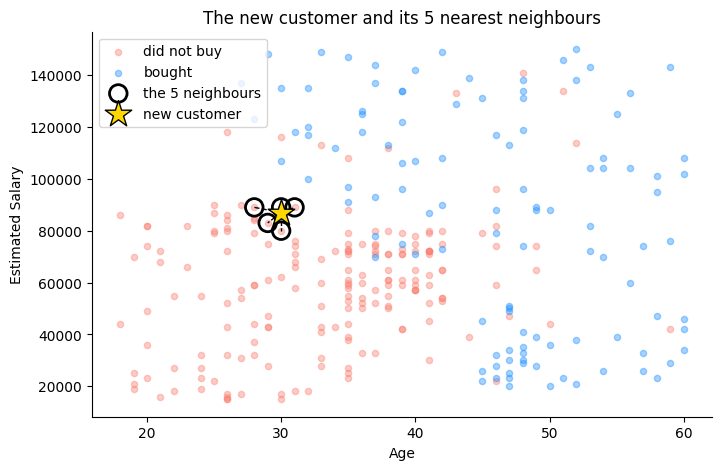

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for label in [0, 1]:
    ax.scatter(X_train[y_train == label, 0], X_train[y_train == label, 1], color=COLORS[label],
               s=20, alpha=0.4, label=['did not buy', 'bought'][label])
nb = X_train[indices[0]]
for p in nb:
    ax.plot([30, p[0]], [87000, p[1]], 'k--', linewidth=1)
ax.scatter(nb[:, 0], nb[:, 1], facecolors='none', edgecolors='black', s=160, linewidths=2, label='the 5 neighbours')
ax.scatter(30, 87000, marker='*', s=400, color='gold', edgecolor='k', zorder=5, label='new customer')
ax.set_xlabel('Age')
ax.set_ylabel('Estimated Salary')
ax.set_title('The new customer and its 5 nearest neighbours')
ax.legend()
plt.show()

## 6. Evaluate on the test set

> ✍️ **Core code: learn this.** Predict all test users and measure performance.

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = classifier.predict(X_test_sc)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred, target_names=['did not buy', 'bought']))

Confusion matrix:
 [[64  4]
 [ 3 29]]

Accuracy: 0.93

               precision    recall  f1-score   support

 did not buy       0.96      0.94      0.95        68
      bought       0.88      0.91      0.89        32

    accuracy                           0.93       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.93      0.93      0.93       100



Reading the confusion matrix `[[TN, FP], [FN, TP]]`:
- **64** non-buyers and **29** buyers predicted correctly.
- **4** false alarms (predicted "buy", did not) and **3** missed buyers.
- **93% accuracy**, well above the ~64% "always say no" baseline.

(See Day 39 for precision, recall and F1 in detail.)

## 7. Visualise the decision boundary

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

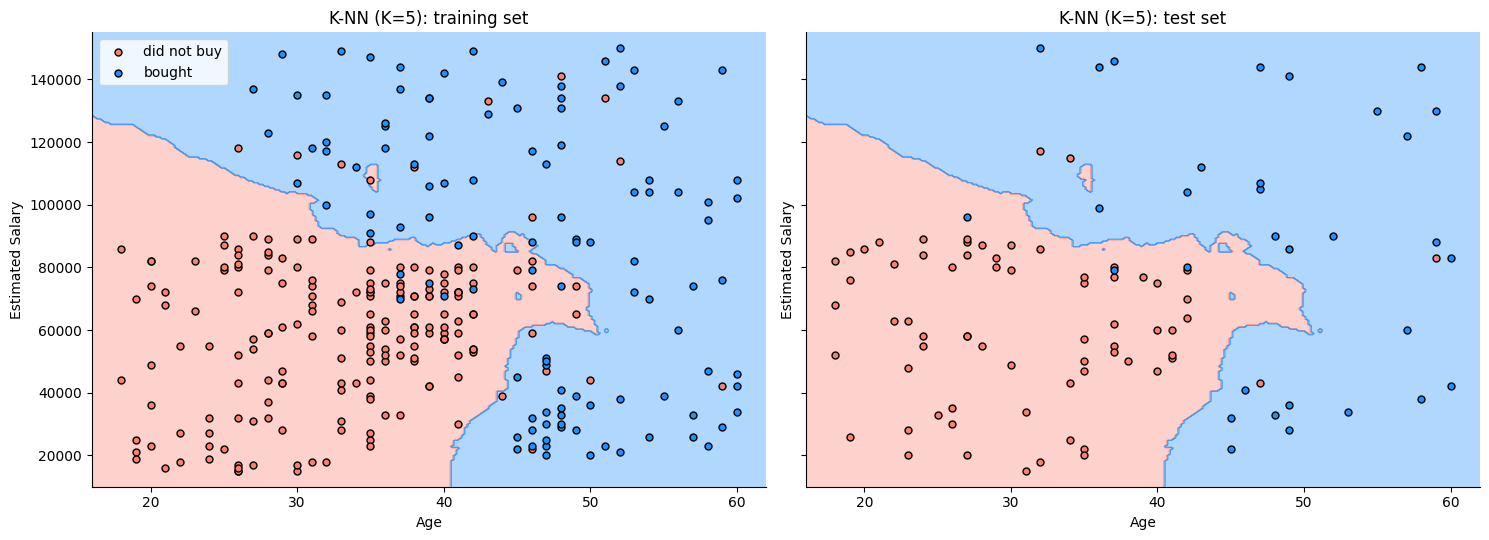

In [12]:
def plot_boundary(ax, model, X_raw, y, transform=None, title=''):
    # Colour every point of a grid by the model's prediction, then draw the real points on top.
    a = np.linspace(X_raw[:, 0].min() - 2, X_raw[:, 0].max() + 2, 250)
    s = np.linspace(X_raw[:, 1].min() - 5000, X_raw[:, 1].max() + 5000, 250)
    A, S = np.meshgrid(a, s)
    grid = np.c_[A.ravel(), S.ravel()]
    if transform is not None:
        grid = transform(grid)
    Z = model.predict(grid).reshape(A.shape)
    ax.contourf(A, S, Z, alpha=0.35, cmap=CMAP)
    for label in [0, 1]:
        ax.scatter(X_raw[y == label, 0], X_raw[y == label, 1], color=COLORS[label], edgecolor='k',
                   s=25, label=['did not buy', 'bought'][label])
    ax.set_xlabel('Age')
    ax.set_ylabel('Estimated Salary')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
plot_boundary(axes[0], classifier, X_train, y_train, sc.transform, 'K-NN (K=5): training set')
plot_boundary(axes[1], classifier, X_test, y_test, sc.transform, 'K-NN (K=5): test set')
axes[0].legend()
plt.tight_layout()
plt.show()

Every pixel is coloured by the class K-NN would predict there. The boundary is **curved and irregular**: K-NN is a
**non-linear** classifier. Compare this with the straight line logistic regression draws (Day 38).

## 8. 🧪 Experiment: what if we forget to scale?

In [13]:
unscaled = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
print("Accuracy WITHOUT scaling:", accuracy_score(y_test, unscaled.predict(X_test)))
print("Accuracy WITH scaling   :", accuracy_score(y_test, y_pred))

Accuracy WITHOUT scaling: 0.83
Accuracy WITH scaling   : 0.93


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

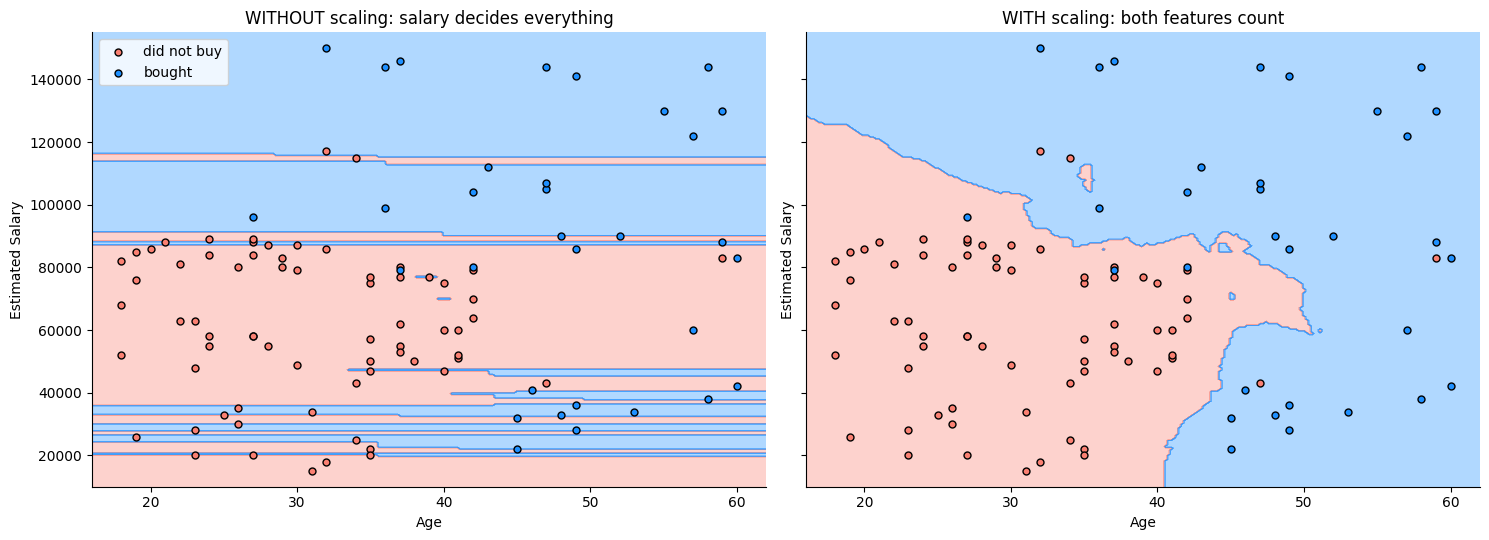

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
plot_boundary(axes[0], unscaled, X_test, y_test, None, 'WITHOUT scaling: salary decides everything')
plot_boundary(axes[1], classifier, X_test, y_test, sc.transform, 'WITH scaling: both features count')
axes[0].legend()
plt.tight_layout()
plt.show()

Without scaling the boundary is made of **horizontal bands**: only salary matters, and age is ignored because its
differences are tiny next to salary differences. Accuracy drops by 10 percentage points. **Always scale before K-NN.**

## 9. 🎯 Choosing K

| K | Behaviour |
|---|---|
| very small (K = 1) | follows every single training point, including noise → **overfitting** (high variance) |
| very large (K ≈ all points) | every prediction becomes the majority class → **underfitting** (high bias) |
| in between | smooth but flexible boundary |

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

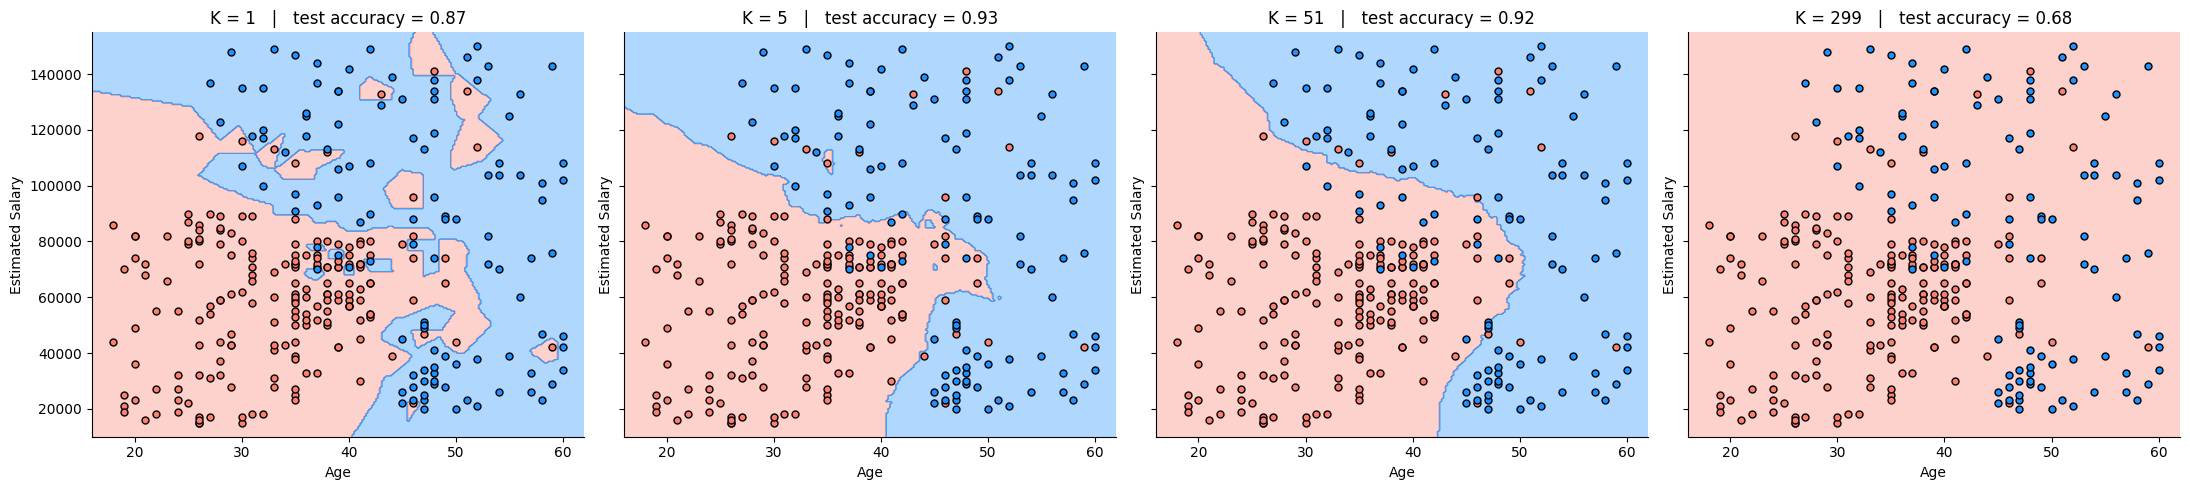

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, k in zip(axes, [1, 5, 51, 299]):
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_sc))
    plot_boundary(ax, m, X_train, y_train, sc.transform, f'K = {k}   |   test accuracy = {acc:.2f}')
plt.tight_layout()
plt.show()

- **K = 1**: islands around individual points, a memorised training set.
- **K = 5**: smooth regions that still follow the data.
- **K = 51**: smoother still, slightly less accurate.
- **K = 299** (every training point): the whole plane is one colour, so it always predicts "did not buy".

### Measuring it: training vs test vs cross-validation accuracy

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

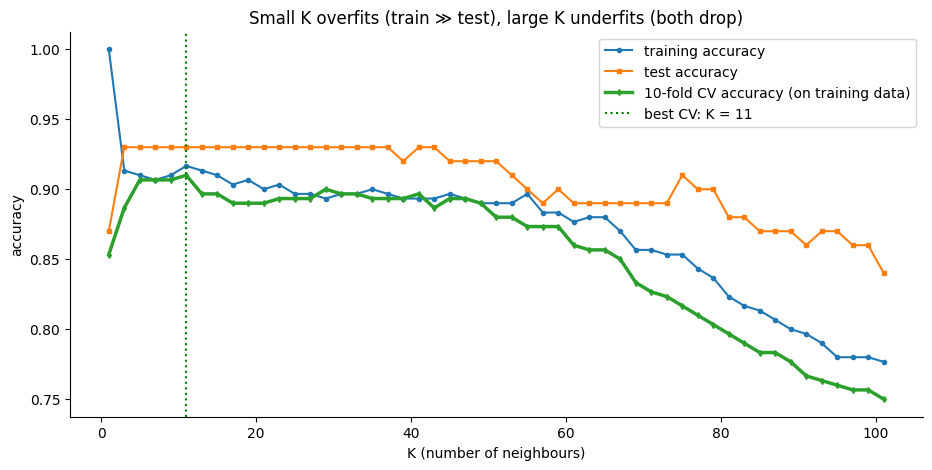

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

ks = list(range(1, 102, 2))
train_acc, test_acc, cv_acc = [], [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_sc, y_train)
    train_acc.append(m.score(X_train_sc, y_train))
    test_acc.append(m.score(X_test_sc, y_test))
    cv_acc.append(cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
                                  X_train, y_train, cv=10).mean())

plt.figure(figsize=(11, 5))
plt.plot(ks, train_acc, 'o-', markersize=3, label='training accuracy')
plt.plot(ks, test_acc, 's-', markersize=3, label='test accuracy')
plt.plot(ks, cv_acc, 'd-', markersize=3, linewidth=2.5, label='10-fold CV accuracy (on training data)')
plt.axvline(ks[int(np.argmax(cv_acc))], color='green', linestyle=':', label=f'best CV: K = {ks[int(np.argmax(cv_acc))]}')
plt.xlabel('K (number of neighbours)')
plt.ylabel('accuracy')
plt.title('Small K overfits (train ≫ test), large K underfits (both drop)')
plt.legend()
plt.show()

- At **K = 1**, training accuracy is a perfect 1.0 (each point is its own nearest neighbour) but test accuracy is lower: **overfitting**.
- As K grows very large, **both** curves fall: **underfitting**.
- We choose K with **cross-validation on the training data**, never with the test set.

### Tuning K (and the voting rule) properly

> ✍️ **Core code: learn this.** A pipeline keeps scaling inside cross-validation, so each fold is scaled using only its own training part.

In [17]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())
param_grid = {
    'kneighborsclassifier__n_neighbors': range(1, 31),
    'kneighborsclassifier__weights': ['uniform', 'distance'],   # distance = closer neighbours get a bigger vote
}
search = GridSearchCV(pipe, param_grid, cv=10)
search.fit(X_train, y_train)               # raw X: the pipeline scales it

print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 3))
print("Test accuracy   :", search.score(X_test, y_test))

Best parameters: {'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'uniform'}
Best CV accuracy: 0.91
Test accuracy   : 0.93


---
## Key takeaways
- K-NN classifies by a **majority vote of the K nearest training points**; it learns no parameters.
- **Scale features first**: forgetting cost us 10 percentage points of accuracy here.
- **Small K overfits, large K underfits**; pick K by cross-validation (odd K avoids ties in binary problems).
- It draws **non-linear** boundaries naturally, but every prediction must search the training set, so it is slow on large data.

## 🧠 Quick check

<details><summary>1. What does K-NN do during training?</summary>

It only stores the training data (a "lazy learner"). All computation happens at prediction time.
</details>

<details><summary>2. Why did accuracy drop without scaling?</summary>

Salary values are ~3,000× larger than age values, so salary dominated the distance and age was effectively ignored.
</details>

<details><summary>3. Why is training accuracy 1.0 at K = 1?</summary>

Each training point's nearest neighbour is itself, so it always "predicts" its own label.
</details>

<details><summary>4. What does K = 299 predict here, and why?</summary>

Always "did not buy": with every training point voting, the majority class wins everywhere.
</details>

➡️ **Next:** `02-EXTRA-knn-from-scratch.ipynb`: build K-NN yourself in about 20 lines.